# Tester_branch에서 성능 확인 진행

In [44]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report


# DT 모델
from sklearn.tree import DecisionTreeClassifier

# xgb 모델
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
wine = load_wine()

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

''' 코드 작성 바랍니다 '''
df = pd.DataFrame(data=wine.data, columns= wine.feature_names)
df['target'] = wine.target
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


####### A 작업자 작업 수행 #######

''' 코드 작성 바랍니다 '''
# 하이퍼 파라미터
dt_params = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 모델 정의
dt_model = DecisionTreeClassifier(random_state=42)

# GridSearchCV로 튜닝
dt_grid_search = GridSearchCV(dt_model, dt_params, cv=5, scoring='accuracy')

# 학습
dt_grid_search.fit(X_train, y_train)


####### B 작업자 작업 수행 #######

''' 코드 작성 바랍니다 '''
# 하이퍼 파라미터
xgb_params = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

# 모델 정의
xgb_model = XGBClassifier(random_state=42)

# GridSearchCV로 튜닝
xgb_grid_search = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy')

# 학습
xgb_grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'max_depth': [3, 5, 7, 9, 15],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy')

# DT 모델링 성능

Best Hyper-parameters {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


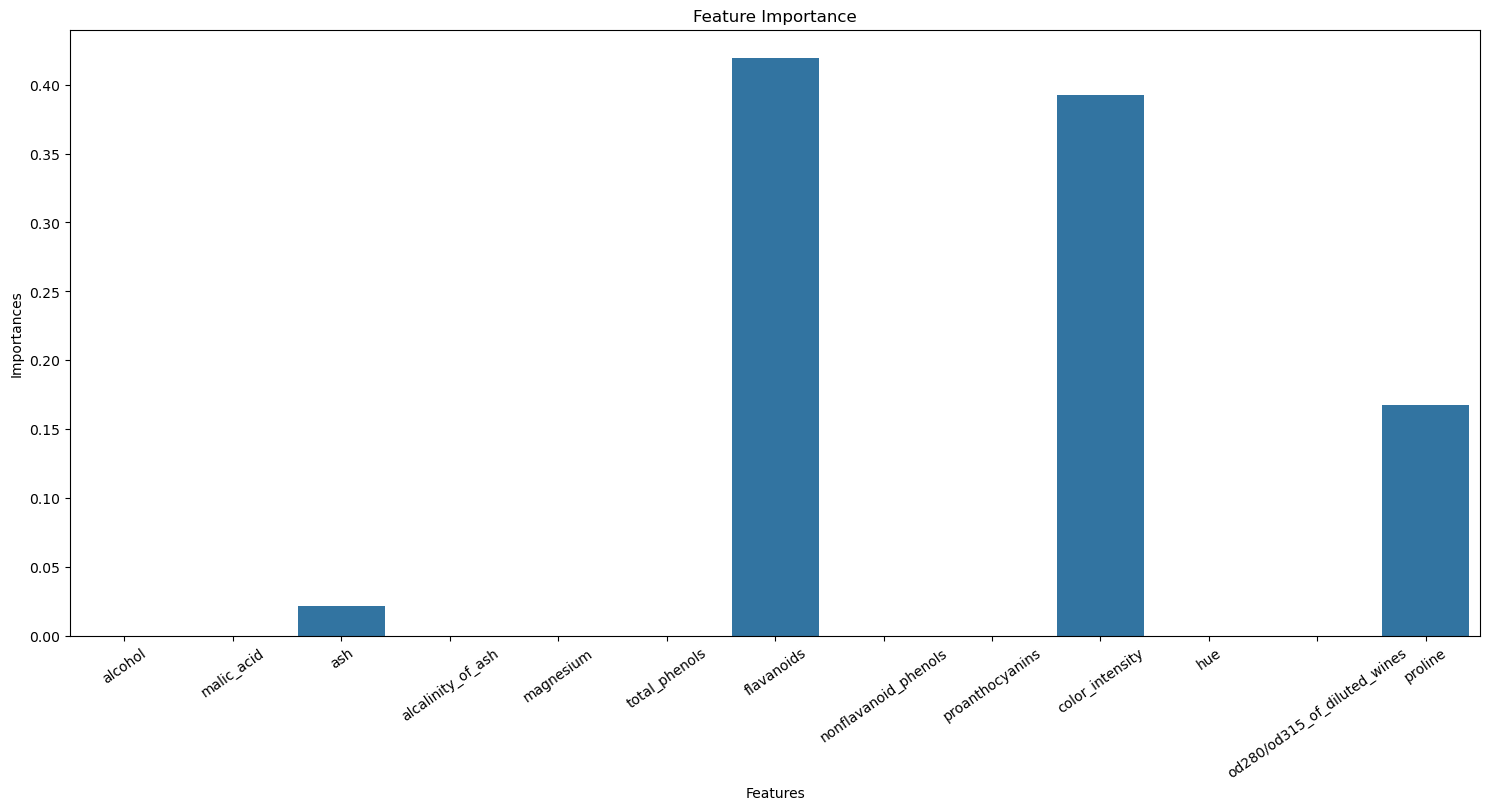

In [45]:
''' 코드를 작성해주세요 '''
# Best Hyper-parameters 출력
print("Best Hyper-parameters", dt_grid_search.best_params_)

# Best Score 출력
print("Best Score", dt_grid_search.best_score_)

# Feature importance 시각화
dt_best_model = dt_grid_search.best_estimator_
importances = pd.Series(dt_best_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(15, 7))
sns.barplot(x=wine.feature_names, y=importances.values)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importances")
plt.tight_layout()
plt.xticks(rotation=35)
plt.show()

<img src="./참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best Hyper-parameters {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score 0.9576354679802955


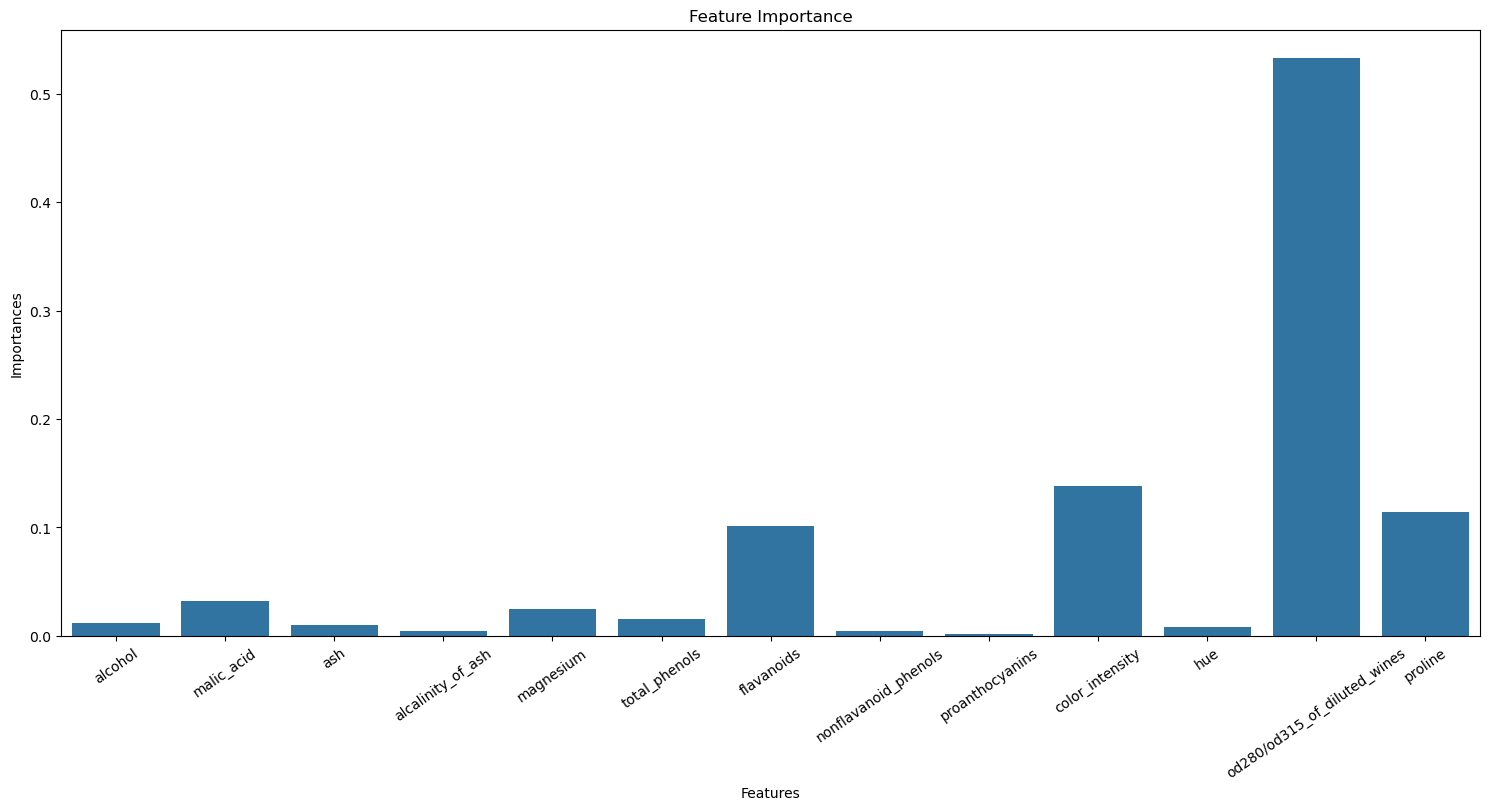

In [46]:
''' 코드를 작성해주세요 '''
# Best Hyper-parameters 출력
print("Best Hyper-parameters", xgb_grid_search.best_params_)

# Best Score 출력
print("Best Score", xgb_grid_search.best_score_)

# Feature importance 시각화
xgb_best_model = xgb_grid_search.best_estimator_
importances = pd.Series(xgb_best_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(15, 7))
sns.barplot(x=wine.feature_names, y=importances.values)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importances")
plt.tight_layout()
plt.xticks(rotation=35)
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



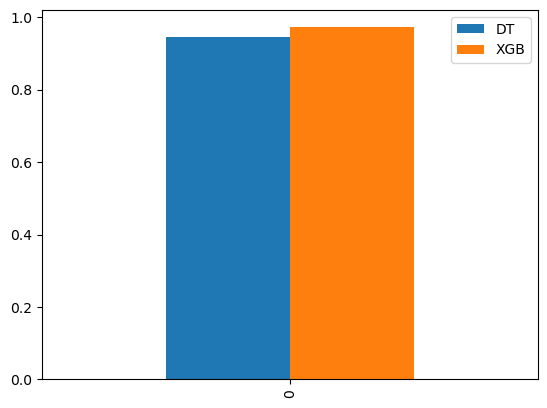

In [47]:
''' 코드를 작성해주세요 '''
# 테스트 데이터에 대한 예측
y_pred_dt = dt_best_model.predict(X_test)
accuracy_dt = accuracy_score(y_test,y_pred_dt)
y_pred_xgb = xgb_best_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test,y_pred_xgb)

# 성능 리포트
print('='*20,'DT 성능 확인','='*20)
print('DT accuracy',accuracy_dt )
print(classification_report(y_test, y_pred_dt))
print('='*20,'XGB 성능 확인','='*20)
print('XGB accuracy',accuracy_xgb )
print(classification_report(y_test, y_pred_xgb))

# 시각화

df = pd.DataFrame({
    'DT': [accuracy_dt],
    'XGB': [accuracy_xgb]
})

df.plot(kind='bar')
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">